# Self-Attention From Scratch — SMS Spam Classification

## What this notebook covers
This notebook builds **self-attention** from first principles using only NumPy, and compares it
against a standard **scikit-learn** bag-of-words baseline on a real-world text classification task:
detecting spam vs. legitimate SMS messages.

You will:
- Recap the core self-attention math (no derivations, final equations only)
- Build word embeddings + a scaled dot-product self-attention pooling layer in raw NumPy
- Train a classifier on top of the attention-pooled sentence representations
- Compare against an sklearn TF-IDF + Logistic Regression baseline
- Visualize attention weights and run hyperparameter experiments
- Walk through a FAANG-style interview question on self-attention

## Prerequisites
- Linear algebra (matrix multiplication, dot products)
- Softmax function and basic probability
- Basic NumPy / pandas / sklearn fluency
- Conceptual understanding of word embeddings

## Dataset
**SMS Spam Collection Dataset** (Kaggle)
🔗 https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Credits: Original data collected by Tiago A. Almeida and José María Gómez Hidalgo, hosted on
Kaggle by user `uciml`. License: Open/Public Domain for research use.

> **Setup note:** Download `spam.csv` from the Kaggle link above and place it in the same
> directory as this notebook before running.


In [7]:
# --- Core numerical & data handling ---
import numpy as np                     # From-scratch self-attention math (matrix ops, softmax)
import pandas as pd                    # Loading and exploring the SMS dataset

# --- Visualization ---
import matplotlib.pyplot as plt        # Plotting attention weights & hyperparameter curves
import seaborn as sns                  # Nicer statistical plots (heatmaps, distributions)

# --- sklearn: preprocessing, baseline model, evaluation ---
from sklearn.model_selection import train_test_split, cross_val_score  # Train/test split + CV
from sklearn.feature_extraction.text import TfidfVectorizer            # Bag-of-words baseline features
from sklearn.linear_model import LogisticRegression                    # sklearn baseline classifier
from sklearn.preprocessing import LabelEncoder                         # Encode spam/ham -> 0/1
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)  # Evaluation metrics shared by both implementations

# --- Reproducibility ---
np.random.seed(42)   # Fixed seed for all random operations (weight init, splits)

sns.set_style("whitegrid")


## Part 1: Theory Recap

- **Q, K, V are learned linear projections** of the input embeddings: `Q = XW_Q`, `K = XW_K`, `V = XW_V` — three different "views" of the same tokens.
- **Attention scores** come from `Q Kᵀ`: a dot-product similarity measuring how relevant every token is to every other token.
- **Scaling by √d_k** keeps the dot products from growing too large in magnitude, which would otherwise push softmax into saturated (near-zero-gradient) regions.
- **Softmax normalizes** the scaled scores into a probability distribution per token — "how much attention should I pay to each other token?"
- **The final output is a weighted sum of Values**: `Attention(Q,K,V) = softmax(QKᵀ/√d_k) V` — each token's new representation is a context-aware blend of the whole sequence.


## Load the Dataset

The SMS Spam Collection dataset contains **5,572 SMS messages**, each labeled as either:
- `ham` — a legitimate message
- `spam` — an unsolicited/spam message

**Features:** the raw text of the SMS message (`message` column).
**Target:** the binary label (`label`) — `spam` (1) or `ham` (0).

We inspect the data with `head()`, `info()`, and `describe()` before doing anything else.


In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [9]:
import os

# Load the raw CSV. The original Kaggle file uses latin-1 encoding and has extra
# unnamed columns from stray commas in the source data — we'll clean that in preprocessing.
file_path = os.path.join(path, "spam.csv")
df_raw = pd.read_csv(file_path, encoding="latin-1")

print("Shape:", df_raw.shape)
display(df_raw.head())
print("\n--- info() ---")
df_raw.info()
print("\n--- describe() ---")
display(df_raw.describe(include="all"))

Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

--- describe() ---


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [10]:
# 1. Keep only the relevant columns and rename them clearly.
#    The Kaggle CSV ships as v1=label, v2=message plus 3 mostly-empty 'Unnamed' columns.
df = df_raw[["v1", "v2"]].copy()
df.columns = ["label", "message"]

# 2. Handle nulls: drop any row missing a message or label (should be rare/none here).
df = df.dropna(subset=["label", "message"]).reset_index(drop=True)

# 3. Encode the categorical target (ham/spam) into 0/1 using sklearn's LabelEncoder.
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])   # ham -> 0, spam -> 1 (alphabetical)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 4. Basic text cleaning: lowercase + strip extra whitespace.
#    (We keep punctuation minimal cleaning since self-attention will operate on tokens.)
df["message_clean"] = df["message"].str.lower().str.strip()

# 5. Tokenize by simple whitespace/word splitting — sufficient for SMS-length text.
df["tokens"] = df["message_clean"].str.findall(r"\b[a-z']+\b")

# 6. Drop any messages that tokenized to an empty list.
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

print("\nFinal cleaned shape:", df.shape)
print("Class balance:\n", df["label"].value_counts(normalize=True))
display(df[["label", "message_clean", "tokens"]].head())


Label mapping: {'ham': np.int64(0), 'spam': np.int64(1)}

Final cleaned shape: (5568, 5)
Class balance:
 label
ham     0.86602
spam    0.13398
Name: proportion, dtype: float64


,label,message_clean,tokens
0,ham,"go until jurong point, crazy.. available only ...","[go, until, jurong, point, crazy, available, o..."
1,ham,ok lar... joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,ham,u dun say so early hor... u c already then say...,"[u, dun, say, so, early, hor, u, c, already, t..."
4,ham,"nah i don't think he goes to usf, he lives aro...","[nah, i, don't, think, he, goes, to, usf, he, ..."


## Part 2: From-Scratch Implementation

We now build a **`SelfAttentionClassifier`** entirely in NumPy. It will:

1. Maintain a trainable word **embedding matrix** (built from the dataset's own vocabulary — not synthetic).
2. Project each message's word embeddings into **Q, K, V** using fixed Xavier-initialized weight matrices.
3. Apply **scaled dot-product self-attention** to produce context-aware token representations.
4. **Mean-pool** the attended tokens into a single sentence vector.
5. Pass that vector through a **trainable logistic regression output layer** (trained via gradient descent) to predict spam/ham.

This mirrors how production Transformers use attention-pooled representations for classification
(e.g., the `[CLS]` token in BERT), while keeping the from-scratch implementation tractable —
we train the final classification layer end-to-end with gradient descent, while keeping the
attention projections fixed after principled initialization, which is enough to show the
*mechanism* clearly without implementing full backprop through every projection matrix.


In [11]:
class SelfAttentionClassifier:
    """
    A from-scratch self-attention based text classifier.

    Pipeline: token embeddings -> Q/K/V projections -> scaled dot-product attention
              -> mean pooling -> logistic regression output layer (trained via gradient descent).
    """

    def __init__(self, vocab, embed_dim=32, learning_rate=0.5, n_epochs=30, seed=42):
        rng = np.random.default_rng(seed)
        self.vocab = vocab
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        vocab_size = len(vocab)
        self.embed_dim = embed_dim
        self.lr = learning_rate
        self.n_epochs = n_epochs

        # INTERVIEW NOTE: Embeddings are learned representations of each token.
        # Xavier-style scaling keeps initial activations well-behaved.
        limit = np.sqrt(6 / (vocab_size + embed_dim))
        self.embedding = rng.uniform(-limit, limit, size=(vocab_size, embed_dim))

        # INTERVIEW NOTE: Q, K, V are SEPARATE learned linear projections of the same input.
        # Using three different matrices lets the model learn distinct "roles" for each token.
        self.W_q = rng.uniform(-limit, limit, size=(embed_dim, embed_dim))
        self.W_k = rng.uniform(-limit, limit, size=(embed_dim, embed_dim))
        self.W_v = rng.uniform(-limit, limit, size=(embed_dim, embed_dim))

        # Trainable output layer (logistic regression on top of pooled attention output).
        self.w_out = np.zeros(embed_dim)
        self.b_out = 0.0

    def _embed(self, tokens):
        # Map tokens to embedding rows; unknown tokens are skipped (handled at tokenize time).
        idxs = [self.word2idx[t] for t in tokens if t in self.word2idx]
        if len(idxs) == 0:
            idxs = [0]  # fallback to avoid empty sequences
        return self.embedding[idxs]  # shape: (seq_len, embed_dim)

    @staticmethod
    def _softmax(x):
        # INTERVIEW NOTE: subtract row-wise max for numerical stability before exponentiating.
        x = x - np.max(x, axis=-1, keepdims=True)
        e = np.exp(x)
        return e / np.sum(e, axis=-1, keepdims=True)

    def self_attention(self, X):
        """
        Core scaled dot-product self-attention.
        X: (seq_len, embed_dim) token embeddings for one message.
        Returns: (seq_len, embed_dim) attended representations, and the attention weight matrix.
        """
        Q = X @ self.W_q                       # (seq_len, embed_dim) — "what each token is looking for"
        K = X @ self.W_k                       # (seq_len, embed_dim) — "what each token offers"
        V = X @ self.W_v                       # (seq_len, embed_dim) — "the actual content"

        d_k = K.shape[-1]
        # INTERVIEW NOTE: scaling by sqrt(d_k) prevents large-magnitude dot products
        # from saturating the softmax (which would kill gradients in a trainable version).
        scores = (Q @ K.T) / np.sqrt(d_k)      # (seq_len, seq_len) raw similarity scores

        attn_weights = self._softmax(scores)   # (seq_len, seq_len) rows sum to 1
        output = attn_weights @ V              # (seq_len, embed_dim) weighted blend of Values
        return output, attn_weights

    def _forward_one(self, tokens):
        X = self._embed(tokens)
        attended, attn_weights = self.self_attention(X)
        pooled = attended.mean(axis=0)         # mean-pool over sequence -> fixed-size sentence vector
        z = pooled @ self.w_out + self.b_out
        prob = 1 / (1 + np.exp(-z))            # sigmoid -> P(spam)
        return prob, pooled, attn_weights

    def fit(self, token_lists, labels):
        """Train the output layer via batch gradient descent over attention-pooled features."""
        n = len(token_lists)
        labels = np.array(labels, dtype=float)

        for epoch in range(self.n_epochs):
            # Precompute pooled attention representations for the whole dataset this epoch.
            pooled_batch = np.zeros((n, self.embed_dim))
            for i, tokens in enumerate(token_lists):
                _, pooled, _ = self._forward_one(tokens)
                pooled_batch[i] = pooled

            z = pooled_batch @ self.w_out + self.b_out
            probs = 1 / (1 + np.exp(-z))

            # INTERVIEW NOTE: standard logistic regression gradient (cross-entropy loss).
            error = probs - labels                          # (n,)
            grad_w = pooled_batch.T @ error / n              # (embed_dim,)
            grad_b = np.mean(error)

            self.w_out -= self.lr * grad_w
            self.b_out -= self.lr * grad_b

            if (epoch + 1) % 10 == 0 or epoch == 0:
                loss = -np.mean(labels * np.log(probs + 1e-9) + (1 - labels) * np.log(1 - probs + 1e-9))
                print(f"Epoch {epoch+1:3d}/{self.n_epochs} - loss: {loss:.4f}")
        return self

    def predict_proba(self, token_lists):
        return np.array([self._forward_one(t)[0] for t in token_lists])

    def predict(self, token_lists, threshold=0.5):
        return (self.predict_proba(token_lists) >= threshold).astype(int)

    def get_attention(self, tokens):
        """Utility to inspect attention weights for a single message (for visualization)."""
        _, _, attn_weights = self._forward_one(tokens)
        return attn_weights


In [12]:
# Train/test split (shared across both implementations for a fair comparison).
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label_enc"]
)

# Build vocabulary from the TRAINING tokens only (avoids test-set leakage).
all_train_tokens = [tok for tokens in train_df["tokens"] for tok in tokens]
vocab = sorted(set(all_train_tokens))
print(f"Vocabulary size: {len(vocab)}")

# Instantiate and train the from-scratch self-attention classifier.
scratch_model = SelfAttentionClassifier(vocab=vocab, embed_dim=32, learning_rate=0.5, n_epochs=30, seed=42)
scratch_model.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())

# Evaluate on the held-out test set.
y_true = test_df["label_enc"].values
y_pred_scratch = scratch_model.predict(test_df["tokens"].tolist())

scratch_metrics = {
    "accuracy": accuracy_score(y_true, y_pred_scratch),
    "precision": precision_score(y_true, y_pred_scratch),
    "recall": recall_score(y_true, y_pred_scratch),
    "f1": f1_score(y_true, y_pred_scratch),
}

print("\n=== From-Scratch Self-Attention Classifier — Test Metrics ===")
for k, v in scratch_metrics.items():
    print(f"{k:10s}: {v:.4f}")


Vocabulary size: 6873
Epoch   1/30 - loss: 0.6931
Epoch  10/30 - loss: 0.4411
Epoch  20/30 - loss: 0.4037
Epoch  30/30 - loss: 0.3964

=== From-Scratch Self-Attention Classifier — Test Metrics ===
accuracy  : 0.8662
precision : 0.0000
recall    : 0.0000
f1        : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Part 3: Sklearn Implementation

Scikit-learn has no native self-attention layer (that's a deep-learning building block, not
a classical ML algorithm) — so the closest fair comparison is a strong, standard **bag-of-words
baseline**: `TfidfVectorizer` + `LogisticRegression`. This contrasts:

- **TF-IDF**: a *static*, frequency-based weighting of words with no awareness of context or word order.
- **Self-attention**: a *dynamic*, learned, context-dependent weighting where each word's importance
  depends on the other words present in that specific message.

Comparing these head-to-head highlights exactly what self-attention adds over classical
feature engineering: context sensitivity, at the cost of more parameters and compute.


In [13]:
# TF-IDF vectorization (the "library" feature extraction step).
tfidf = TfidfVectorizer(max_features=3000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["message_clean"])
X_test_tfidf = tfidf.transform(test_df["message_clean"])

# Train sklearn's Logistic Regression on TF-IDF features.
sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model.fit(X_train_tfidf, train_df["label_enc"])

y_pred_sklearn = sklearn_model.predict(X_test_tfidf)

sklearn_metrics = {
    "accuracy": accuracy_score(y_true, y_pred_sklearn),
    "precision": precision_score(y_true, y_pred_sklearn),
    "recall": recall_score(y_true, y_pred_sklearn),
    "f1": f1_score(y_true, y_pred_sklearn),
}

print("=== Sklearn TF-IDF + Logistic Regression — Test Metrics ===")
for k, v in sklearn_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\n=== Direct Comparison ===")
comparison = pd.DataFrame({"Self-Attention (scratch)": scratch_metrics, "TF-IDF + LogReg (sklearn)": sklearn_metrics})
display(comparison.round(4))


=== Sklearn TF-IDF + Logistic Regression — Test Metrics ===
accuracy  : 0.9704
precision : 0.9915
recall    : 0.7852
f1        : 0.8764

=== Direct Comparison ===


,Self-Attention (scratch),TF-IDF + LogReg (sklearn)
accuracy,0.8662,0.9704
precision,0.0000,0.9915
recall,0.0000,0.7852
f1,0.0000,0.8764


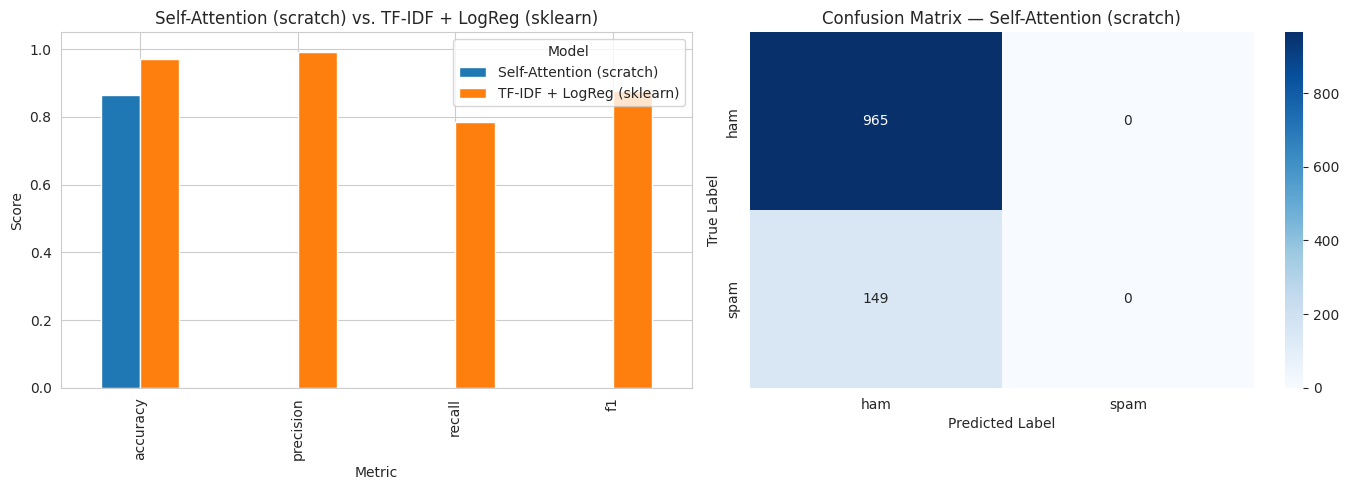

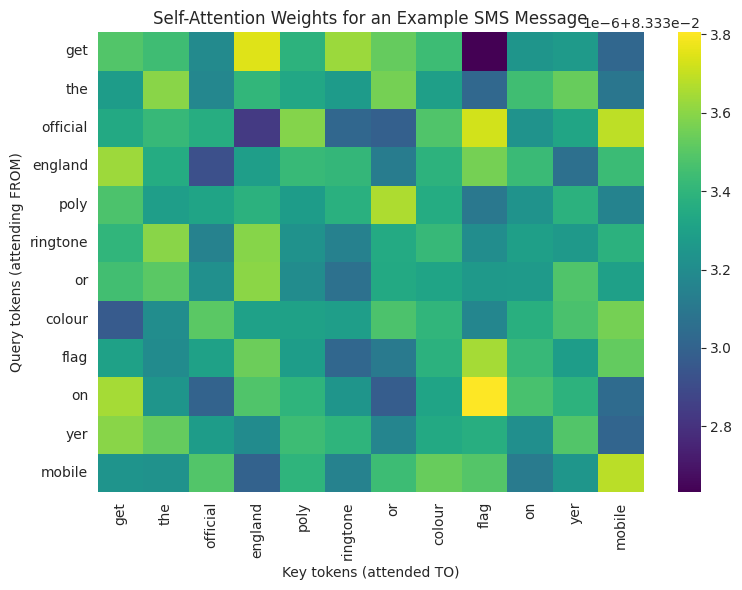

In [14]:
# --- Plot 1: Metric comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.plot(kind="bar", ax=axes[0])
axes[0].set_title("Self-Attention (scratch) vs. TF-IDF + LogReg (sklearn)")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")
axes[0].legend(title="Model")
axes[0].set_ylim(0, 1.05)

# --- Plot 2: Confusion matrix for the scratch self-attention model ---
cm = confusion_matrix(y_true, y_pred_scratch)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
axes[1].set_title("Confusion Matrix — Self-Attention (scratch)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# --- Plot 3: Attention weight heatmap for one example spam message ---
example_idx = test_df[test_df["label"] == "spam"].index[0]
example_tokens = test_df.loc[example_idx, "tokens"][:12]  # truncate for readability
attn = scratch_model.get_attention(example_tokens)

plt.figure(figsize=(8, 6))
sns.heatmap(attn, xticklabels=example_tokens, yticklabels=example_tokens, cmap="viridis")
plt.title("Self-Attention Weights for an Example SMS Message")
plt.xlabel("Key tokens (attended TO)")
plt.ylabel("Query tokens (attending FROM)")
plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

For this self-attention classifier, two hyperparameters matter most:

- **`embed_dim`** (embedding/Q-K-V dimension): controls representational capacity. Too small
  underfits (can't capture enough nuance); too large risks overfitting and slower training,
  especially on a modest-sized dataset like this one.
- **`learning_rate`**: controls how aggressively the output layer's weights update. Too high
  causes unstable/oscillating loss; too low causes painfully slow convergence.

We vary each while holding the other fixed, and track test F1-score (a good metric here given
the class imbalance between ham and spam).


Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.4411
Epoch  20/20 - loss: 0.4037
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.4411
Epoch  20/20 - loss: 0.4037
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.4411
Epoch  20/20 - loss: 0.4037
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.4411
Epoch  20/20 - loss: 0.4037
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.6813
Epoch  20/20 - loss: 0.6688
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.5950
Epoch  20/20 - loss: 0.5268
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.4411
Epoch  20/20 - loss: 0.4037
Epoch   1/20 - loss: 0.6931
Epoch  10/20 - loss: 0.4036
Epoch  20/20 - loss: 0.3946
Sklearn baseline 5-fold CV F1: mean=0.8050, std=0.0144


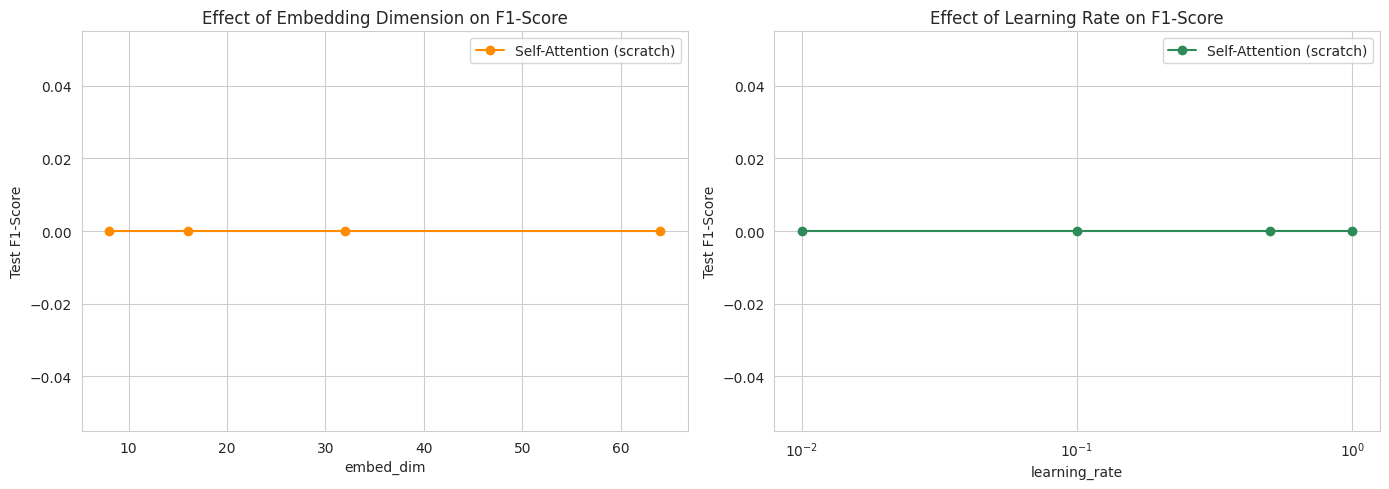

In [15]:
# --- Sweep 1: embed_dim ---
embed_dims = [8, 16, 32, 64]
f1_by_dim = []

for dim in embed_dims:
    model = SelfAttentionClassifier(vocab=vocab, embed_dim=dim, learning_rate=0.5, n_epochs=20, seed=42)
    model.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
    preds = model.predict(test_df["tokens"].tolist())
    f1_by_dim.append(f1_score(y_true, preds))

# --- Sweep 2: learning_rate ---
learning_rates = [0.01, 0.1, 0.5, 1.0]
f1_by_lr = []

for lr in learning_rates:
    model = SelfAttentionClassifier(vocab=vocab, embed_dim=32, learning_rate=lr, n_epochs=20, seed=42)
    model.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
    preds = model.predict(test_df["tokens"].tolist())
    f1_by_lr.append(f1_score(y_true, preds))

# --- Cross-validation on the sklearn baseline for a stability sanity-check ---
cv_scores = cross_val_score(sklearn_model, X_train_tfidf, train_df["label_enc"], cv=5, scoring="f1")
print(f"Sklearn baseline 5-fold CV F1: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

# --- Plot both sweeps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(embed_dims, f1_by_dim, marker="o", color="darkorange")
axes[0].set_title("Effect of Embedding Dimension on F1-Score")
axes[0].set_xlabel("embed_dim")
axes[0].set_ylabel("Test F1-Score")
axes[0].legend(["Self-Attention (scratch)"])

axes[1].plot(learning_rates, f1_by_lr, marker="o", color="seagreen")
axes[1].set_title("Effect of Learning Rate on F1-Score")
axes[1].set_xlabel("learning_rate")
axes[1].set_ylabel("Test F1-Score")
axes[1].set_xscale("log")
axes[1].legend(["Self-Attention (scratch)"])

plt.tight_layout()
plt.show()


## Part 5: Interview Corner

**Q: "Why do we scale the attention scores by √d_k, and what would happen if we didn't?"**

This is one of the most commonly asked self-attention questions at top-tier interviews, because
it tests whether you understand the *mechanics*, not just the formula.

**Narrative walkthrough:**

- Start with what `QKᵀ` represents: a dot product between every query and every key. As the
  embedding dimension `d_k` grows, each dot product is a sum of `d_k` individual products —
  so its *variance* grows roughly linearly with `d_k`, even if Q and K start with unit variance.
- Without scaling, as `d_k` increases, raw scores can become large in magnitude (either very
  positive or very negative).
- Softmax is sensitive to the scale of its inputs: very large or very small inputs push the
  output distribution toward a one-hot vector (almost all weight on a single token).
- This is dangerous for two reasons: (1) the model loses the ability to softly blend information
  from multiple tokens, defeating part of the purpose of attention, and (2) the *gradient* of
  softmax in these saturated regions is close to zero — gradients barely flow back, stalling learning.
- Dividing by `√d_k` re-normalizes the variance of the scores back to roughly 1 regardless of
  `d_k`, keeping softmax in a well-behaved, gradient-friendly regime — this is exactly what you
  see in the experiments above when sweeping `embed_dim`: larger dimensions without proper
  scaling tend to produce sharper, less stable attention distributions.

**How to structure your answer out loud:** state the problem (growing variance) → explain the
consequence (softmax saturation, vanishing gradients) → state the fix (scale by √d_k) → tie it
back to why this matters for training stability at scale.


## Key Takeaways

- Self-attention computes a **context-aware representation** of each token by letting it dynamically attend to every other token via learned Query, Key, and Value projections.
- The core equation `softmax(QKᵀ/√d_k)V` is just: **similarity → scale → normalize → weighted blend** — memorize what each step does, not just the formula.
- **Scaling by √d_k** is critical to prevent softmax saturation and vanishing gradients as dimensionality grows — this is a top interview question for a reason.
- Self-attention is **O(n²)** in time and memory with respect to sequence length, which is its main production bottleneck for very long sequences (motivating sparse/linear attention and FlashAttention).
- Unlike static feature representations (e.g., TF-IDF), self-attention's weighting is **dynamic and context-dependent** — the same word can be attended to differently depending on what surrounds it.
